# Usability: Plotting
### some neuroscience data
30 June 2025<br>
NRSC 7657<br>
Daniel J Denman and John Thompson<br>
University of Colorado Anschutz<br>
<br>

We'll start with the workhorse of plotting, matplotlib. It has flexibility and deep functionality, and many other packages rely on it in some way. If they don't they are going to end up doing the drawing, managing what your graphics card does directly, often then relying on `PyQt`. All of these have to eventually converge there, as all things that have a graphical component do.[This is mostly trivia, but may come in handdy] 

import syntax:

In [1]:
import matplotlib.pyplot as plt

The terminology:

![matplotlib anatomy](https://matplotlib.org/stable/_images/anatomy.png)
<br>
https://matplotlib.org/stable/tutorials/introductory/usage.html#sphx-glr-tutorials-introductory-usage-py

one useful resource is the gallery of types of plots: https://matplotlib.org/stable/gallery/index.html where you can get code snippets from plots that look close to what you want to be plotting.
<br> it is also true that `matplotlib` is one of the most effective areas for LLM produced code, so asking an AI assistant how to use matplotlib to make a certain kind of plot (e.g., "make a box plot with confidence intervals overlaid on individual data points using matplotlib") is likely to more effective than asking one to make an algorithm.
<br>
<br> for this exercise, let's grab some data first

In [2]:
import pandas as pd
df = pd.read_csv('../Week2/iris.csv')

In [3]:
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## Figures and Axes


(0.0, 0.5)

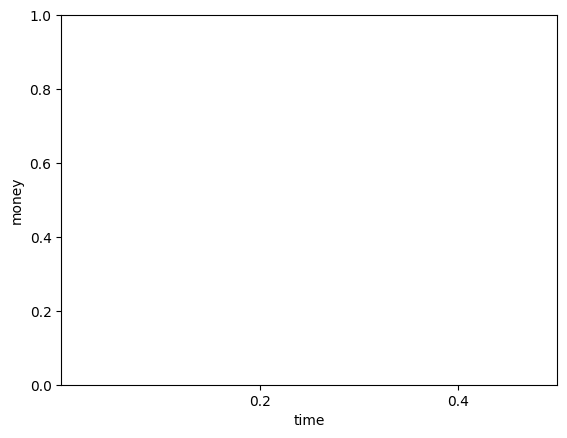

In [4]:
fig, ax = plt.subplots(1,1)
ax.set_xlabel('time')
ax.set_ylabel('money')
ax.set_xticks([0.2,0.4])
ax.set_xlim(0,0.5)

## Axis
modifying properties using `axis` objects, for example parameters of the ticks and labels

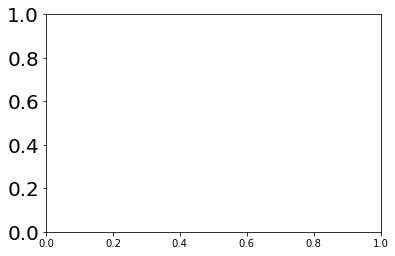

In [15]:
fig, ax = plt.subplots(1,1)
ax.tick_params(axis='x',which='minor',labelsize=4)
ax.tick_params(axis='y',which='major',labelsize=20)

## Artist
everything is an Artist, these are the entities that get drawn. `Figures` and `Axes` are Artists; other things (lines, shapes, labels, text) are associated with a particular axis
<br>

## Q1: access the Figure object we made in the cell above, and set the `face color` to green. 
note: you might successfully set the face color to green, but to see the results you will need to run `fig` on its own line

### The plot object

In [9]:
df.columns = ['sepallength','sepalwidth','petallength','petalwidth','variety']

In [10]:
df.variety.unique()

array(['Setosa', 'Versicolor', 'Virginica'], dtype=object)

the quickest way to create a plot object: provide just the y data, using the position in the 1-d array as the implicit x data:

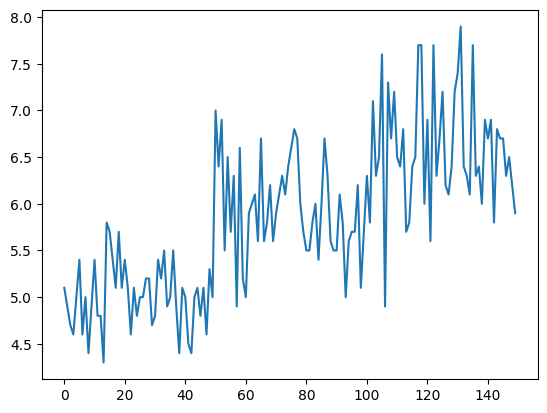

In [11]:
plt.plot(df.sepallength)


second quickest plot version: explicitly provide the x data (first) and the y data (second):

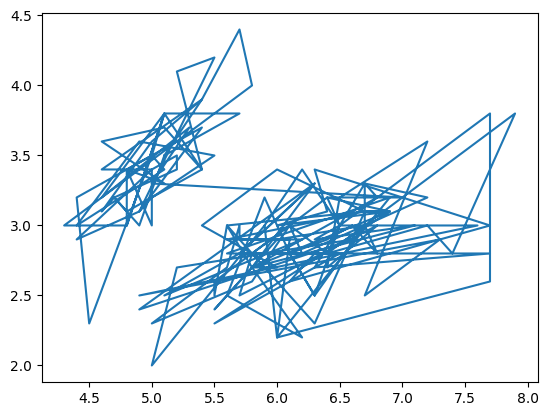

In [12]:
plt.plot(df.sepallength,df.sepalwidth)

if you need to access the plot or axis object though, you'll need to use the special `plt.gcf()` and `plt.gca()` functions: "get current figure" and "get current axis", respectively:

Text(0, 0.5, 'sepal width')

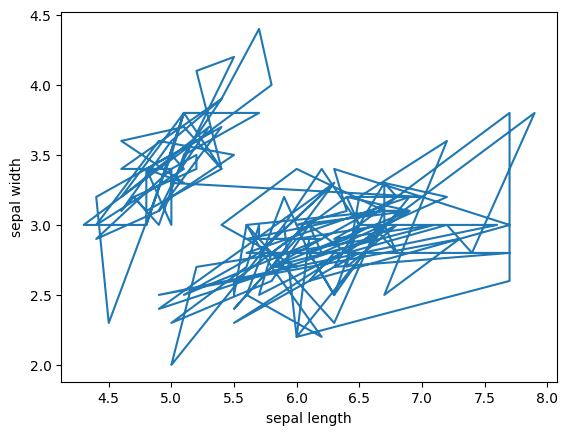

In [ ]:
plt.plot(df.sepallength,df.sepalwidth)
plt.gca().set_xlabel('sepal length')
plt.gca().set_ylabel('sepal width')
plt.gcf().savefig('example_plot.png')

you can also explicitly create figure and axis objects that you can use later. this is a little more code but will be cleaner with more complicated plotting.

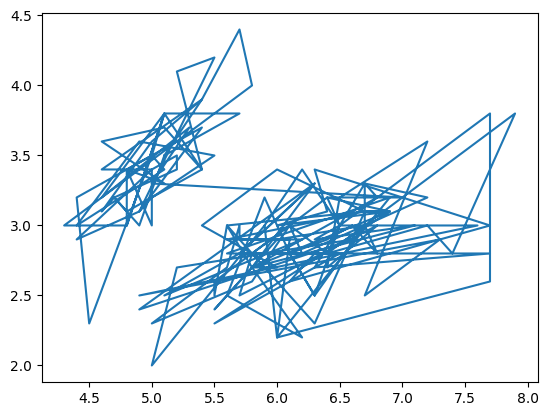

In [16]:
fig, ax = plt.subplots(1,1)
ax.plot(df.sepallength,df.sepalwidth)

## a note on [backends](https://matplotlib.org/stable/users/explain/figure/backends.html)
for notebooks, we are mostly wanting to use `matplotlib` for "inline" plots that pop up in between the cells as we are working. this is only one of the python use cases for plotting - you might want to make specific kond of plots, or make a gui, or more interactive plots. for this, you can change what compiled plotting code it uses, while the "frontend" `matplotlib` code you use remains the same.

In [17]:
import matplotlib

In [18]:
matplotlib.get_backend()

'module://matplotlib_inline.backend_inline'

In [19]:
%matplotlib --list

Available matplotlib backends: ['tk', 'gtk', 'gtk3', 'gtk4', 'wx', 'qt4', 'qt5', 'qt6', 'qt', 'osx', 'nbagg', 'webagg', 'notebook', 'agg', 'svg', 'pdf', 'ps', 'inline', 'ipympl', 'widget']


changing the backend can be done in a `Jupyter` notebook using a `magic` command, which is preceded by a `%`:

In [ ]:
%matplotlib qt

lets make a qt plot, which allows a little more manual tweaking after plotting than a typical inline plot:

In [22]:
plt.plot(df.sepallength,df.sepalwidth,'<-')

## Q2 Where is this plot? is it in a cell? find it and manually change the axis labels to match the x and y values plotted (`sepallength` and `sepalwidth`)

## Q3 change the backend back to `inline`

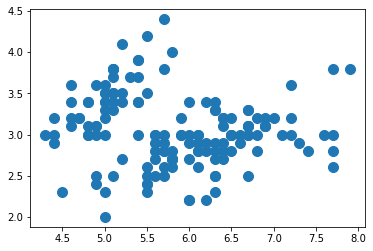

In [59]:
plt.scatter(df.sepallength,df.sepalwidth,s=100)

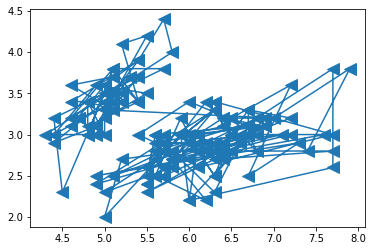

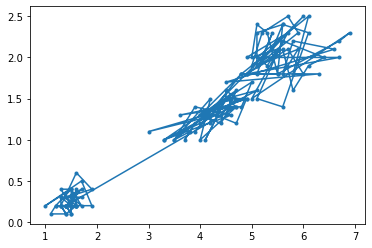

In [68]:
plt.plot(df.sepallength,df.sepalwidth,marker='<',markersize=12)
plt.figure()
plt.plot(df.petallength,df.petalwidth,marker='o',markersize=3)

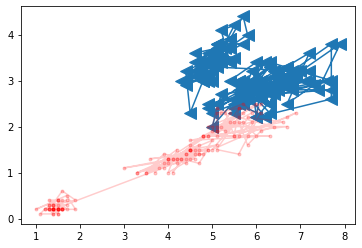

In [82]:
plt.plot(df.sepallength,df.sepalwidth,marker='<',markersize=12)
plt.plot(df.petallength,df.petalwidth,marker='o',markersize=3,color='red',alpha=0.2)

In [88]:
import matplotlib.pyplot as plt

making plots with multiple panels:

Text(0.5, 1.0, 'petal')

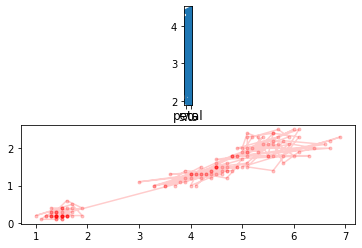

In [95]:
fig,ax = plt.subplots(2,1)
ax[0].plot(df.sepallength,df.sepalwidth,marker='<',markersize=12)
ax[1].plot(df.petallength,df.petalwidth,marker='o',markersize=3,color='red',alpha=0.2)
ax[0].set_aspect(20)
ax[1].set_title('petal')

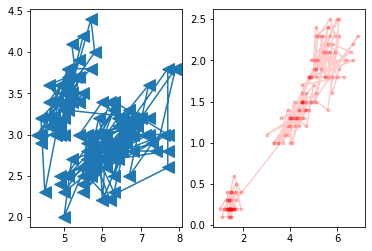

In [96]:
fig,ax = plt.subplots(1,2)
ax[0].plot(df.sepallength,df.sepalwidth,marker='<',markersize=12)
ax[1].plot(df.petallength,df.petalwidth,marker='o',markersize=3,color='red',alpha=0.2)


## Q4 make a 2 by 2 grid of plots and fill it with scatters of different things, all differnt colors and shapes, from the `df`

# image plotting: heatmaps and other things in 2D plots

In [24]:
import numpy as np

In [25]:
im = np.array([[1,2],[3,4]])

In [26]:
im

array([[1, 2],
       [3, 4]])

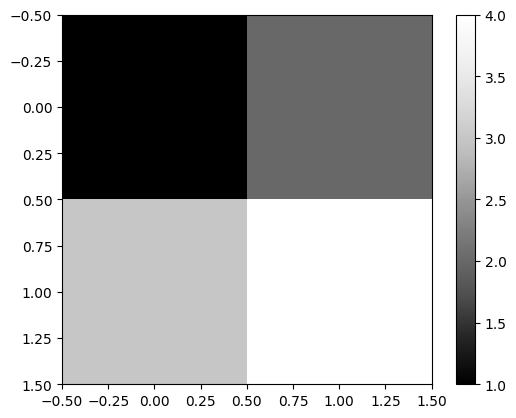

In [29]:
plt.imshow(im,cmap=plt.cm.Greys_r)
plt.colorbar()

In [30]:
im2 = plt.imread('../Week4/forNRSC7657.png')

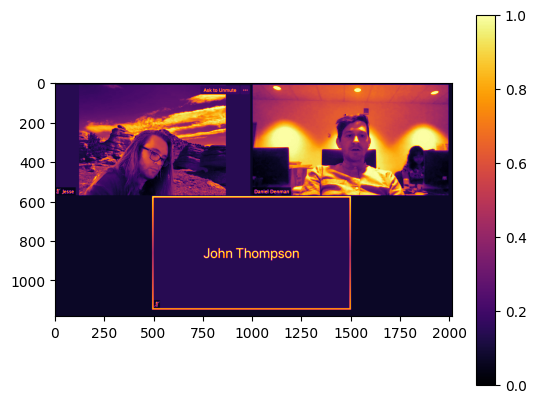

In [33]:
plt.imshow(im2[:,:,0],cmap=plt.cm.inferno)
plt.colorbar()

## Q5 what are the dimensions of im2? what do each of these dimensions mean?

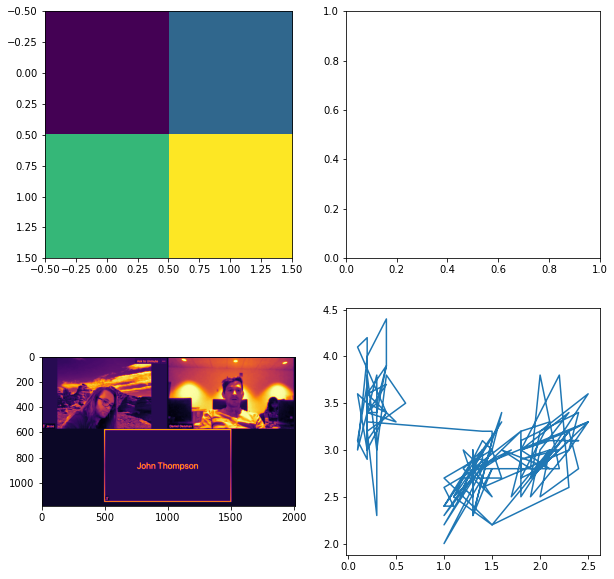

In [129]:
fig,ax=plt.subplots(2,2,figsize=(10,10))
c1 = ax[0][0].imshow(im)
c2 = ax[1][0].imshow(im2[:,:,0],cmap=plt.cm.inferno)
ax[1][1].plot(df.petalwidth,df.sepalwidth)

### matplotlib 3d plots

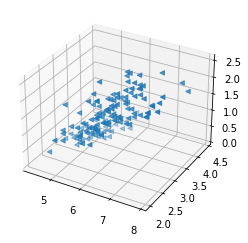

In [125]:
f = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter3D(df.sepallength,df.sepalwidth,df.petalwidth,marker='<')

# Seaborn
built on top of matplotib, makes nice plots and works natively with `pandas` `DataFrame`s

In [130]:
import seaborn as sns

In [131]:
df.head()

,sepallength,sepalwidth,petallength,petalwidth,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


<AxesSubplot:xlabel='sepallength', ylabel='sepalwidth'>

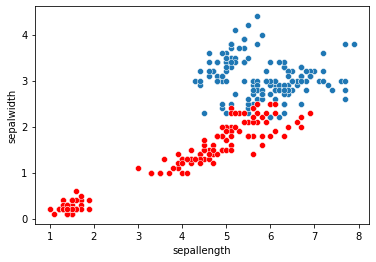

In [134]:
sns.scatterplot(data=df,x='sepallength',y='sepalwidth')
sns.scatterplot(data=df,x='petallength',y='petalwidth',color='red')

## Q6 make two side-by-side plots of sepal length and sepal width, in the same figure object, one with `matplotlib` and one with `seaborn`
note: you'll need to specify the axis object that seaborn uses, but you can do this

<AxesSubplot:xlabel='sepallength', ylabel='sepalwidth'>

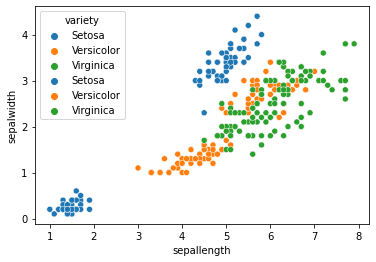

In [136]:
sns.scatterplot(data=df,x='sepallength',y='sepalwidth',hue='variety')
sns.scatterplot(data=df,x='petallength',y='petalwidth',hue='variety')

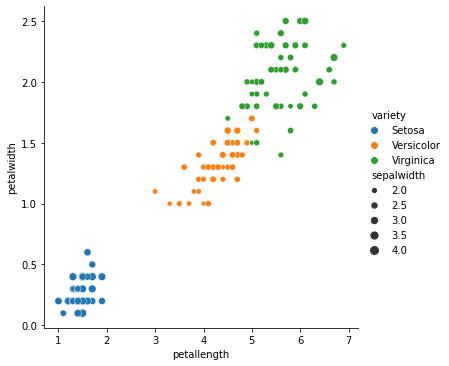

In [137]:
sns.relplot(data=df,x='petallength',y='petalwidth',hue='variety',size='sepalwidth')

`seaborn` has all sorts of builtins that work natively with `pandas DataFrames`, but can also be used with other data types. examples in the gallery: https://seaborn.pydata.org/examples/index.html 

<AxesSubplot:xlabel='variety', ylabel='petalwidth'>

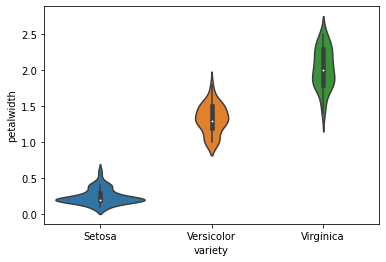

In [139]:
sns.violinplot(data=df,x='variety',y='petalwidth')

### palettes
seaborn also has convenient ways to manage the default colors, for when you want to define a custom set of colors for your paper to match your project or your lab's aesthetics

In [160]:
sns.color_palette('hls',3)

[(0.86, 0.3712, 0.33999999999999997),
 (0.33999999999999997, 0.86, 0.3712),
 (0.3712, 0.33999999999999997, 0.86)]

In [157]:
sns.set_palette(sns.color_palette('hls',3))

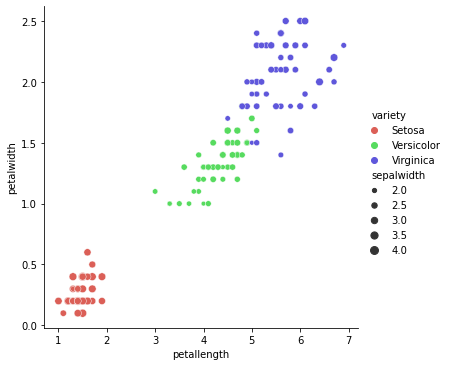

In [158]:
sns.relplot(data=df,x='petallength',y='petalwidth',hue='variety',size='sepalwidth')

## Q7 use the seaborn example gallery to make a stacked histogram of sepal width colored by the variety 

In [ ]:
sns.histplot(
    diamonds,
    x="price", hue="cut",
    multiple="stack",
    palette="light:m_r",
    edgecolor=".3",
    linewidth=.5,
    log_scale=True,
)

## ipywidgets and interactive plotting
we made an interactive-ish plot using the qt backend above, but we might also want to make custom plots that react to user input in real time. to do so, we can install an extra package. This can be a tricky install but give it a try.

In [ ]:
!pip install ipywidgets


In [35]:
import ipywidgets as widgets

In [ ]:
x1 = widgets.IntSlider(description='x max',continuos_update=True)
y1 = widgets.IntSlider(description='y max',continuos_update=True)
widgets.VBox([x1,y1])

In [44]:
@widgets.interact(x1=7,y1=7)
def iris_scatter(x1,y1):
    f,ax = plt.subplots(1,1)
    ax.plot(df.sepallength,df.sepalwidth,marker='<',markersize=12,color='b')
    ax.plot(df.petallength,df.petalwidth,marker='o',markersize=3,color='red',alpha=0.2)
    
    ax.set_xlim(0,x1)
    ax.set_ylim(0,y1)
    

interactive(children=(IntSlider(value=7, description='x1', max=21, min=-7), IntSlider(value=7, description='y1…

## Q8 adjust the x-axis max to 12 and y-axis max to 8 in the interactive plot above

## Bokeh
https://demo.bokeh.org/
<br>
Bokeh is a fantastic package for interactive plotting and dashboards. this will create an interactive plot in a browser window (using a JavaScript client)

In [168]:
!pip install bokeh

In [38]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

In [39]:
p=figure()

In [40]:
p.circle(df.sepallength,df.sepalwidth)
p.circle(df.petallength,df.petalwidth)

GlyphRenderer(id='p1044', ...)

In [41]:
show(p)

you can also output the JavaScript object directly into a notebook

In [42]:
output_notebook()

Loading BokehJS ...

In [43]:
p2=figure()
p2.circle(df.sepallength,df.sepalwidth)
p2.circle(df.petallength,df.petalwidth)

GlyphRenderer(id='p1097', ...)

In [182]:
show(p)